    Objective

Objective:
The objective of this phase is to identify unusual market behavior by combining traditional financial indicators with spectral features extracted using a rolling Fast Fourier Transform (FFT). Instead of relying solely on price movements, this approach captures hidden frequency-domain characteristics of the market and uses an unsupervised machine learning algorithm (Isolation Forest) to detect anomalous trading periods.

--------------------------------------------------------------------------------

    Import Libraries

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.fft import fft
from scipy.stats import entropy

    Load Feature Dataset

In [13]:
df = pd.read_csv("../data/aapl_features.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,id,ticker,open,high,low,close,volume,returns,log_returns,volatility,MA20,MA50
0,2023-03-15,50,AAPL,148.894,150.923,147.643,150.666,77167900,0.002615,0.002612,0.015158,148.02275,142.48100
1,2023-03-16,51,AAPL,149.849,154.084,149.337,153.483,76161100,0.018697,0.018524,0.015424,148.04835,143.09100
2,2023-03-17,52,AAPL,153.710,154.360,151.937,152.646,98944600,-0.005453,-0.005468,0.015282,148.11185,143.65890
3,2023-03-20,53,AAPL,152.715,155.423,151.809,155.009,73641400,0.015480,0.015362,0.015507,148.35065,144.30040
4,2023-03-21,54,AAPL,154.931,156.979,154.163,156.861,73938300,0.011948,0.011877,0.014134,148.88245,144.88848


In [14]:
window_size = 20

energy_list = []

entropy_list = []

frequency_list = []

    Rolling FFT

Instead of computing a single FFT over the entire dataset, a 20-day rolling window is used. For each window, spectral energy, spectral entropy, and dominant frequency are extracted. This provides localized frequency-domain information that evolves over time and can be used as input features for anomaly detection.

In [15]:
for i in range(window_size, len(df)):

    window = df["returns"].iloc[
        i-window_size:i
    ]

    fft_values = fft(window)

    amplitude = np.abs(fft_values)

    frequencies = np.fft.fftfreq(
        len(window)
    )

    positive = frequencies > 0

    freq = frequencies[positive]

    amp = amplitude[positive]

    energy = np.sum(amp**2)

    probability = amp / np.sum(amp)

    ent = entropy(probability)

    dominant_freq = freq[np.argmax(amp)]

    energy_list.append(energy)

    entropy_list.append(ent)

    frequency_list.append(dominant_freq)

In [16]:
df = df.iloc[window_size:].copy()

In [17]:
df["rolling_energy"] = energy_list

df["rolling_entropy"] = entropy_list

df["rolling_frequency"] = frequency_list

In [18]:
df.head()

,date,id,ticker,open,high,low,close,volume,returns,log_returns,volatility,MA20,MA50,rolling_energy,rolling_entropy,rolling_frequency
20,2023-04-13,70,AAPL,159.175,163.282,158.968,163.046,68445600,0.034110,0.033541,0.013099,158.41740,152.44276,0.022909,2.106895,0.1
21,2023-04-14,71,AAPL,162.090,163.794,161.332,162.701,49386500,-0.002116,-0.002118,0.012693,158.87830,152.83672,0.031349,2.082441,0.1
22,2023-04-17,72,AAPL,162.583,162.878,161.539,162.721,41516200,0.000123,0.000123,0.012558,159.38205,153.12508,0.028105,2.076390,0.3
23,2023-04-18,73,AAPL,163.577,164.867,163.134,163.942,49923000,0.007504,0.007476,0.012274,159.82870,153.36548,0.027047,2.063498,0.3
24,2023-04-19,74,AAPL,163.282,165.606,163.026,165.084,47720200,0.006966,0.006942,0.012130,160.23985,153.68320,0.025063,2.074684,0.3


Energy

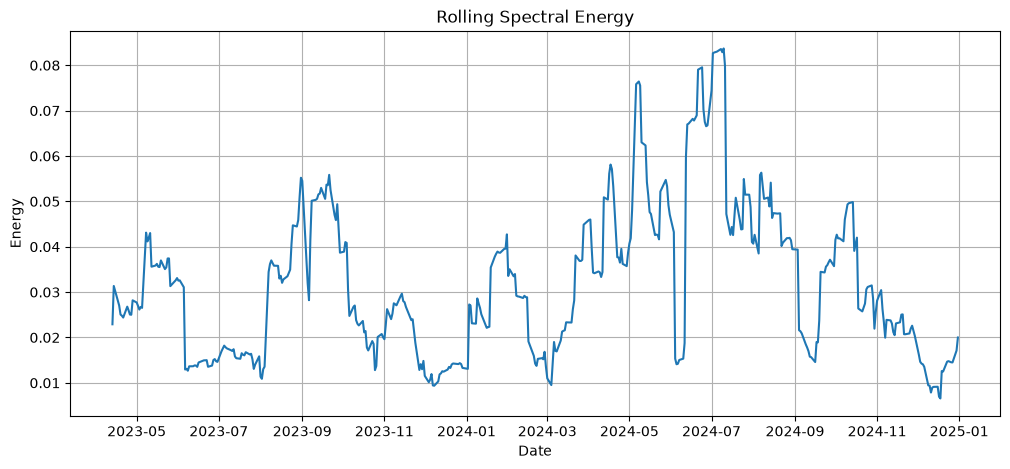

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["rolling_energy"]
)

plt.title("Rolling Spectral Energy")

plt.xlabel("Date")

plt.ylabel("Energy")

plt.grid(True)

plt.show()

Entropy

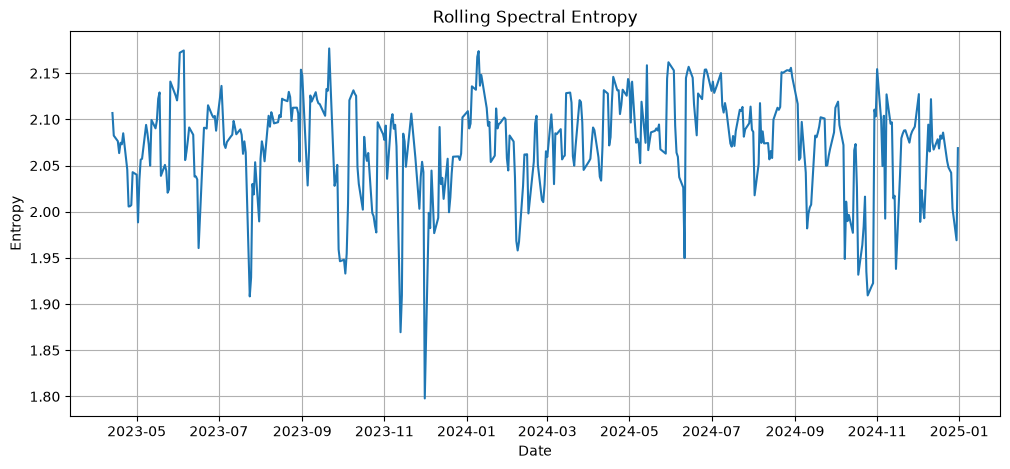

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["rolling_entropy"]
)

plt.title("Rolling Spectral Entropy")

plt.xlabel("Date")

plt.ylabel("Entropy")

plt.grid(True)

plt.show()

In [21]:
#High energy: strong periodic activity

#High entropy: chaotic market

     MODEL 1: ISOLATION FOREST

In [27]:
pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


    Select Features

In [28]:
features = [
    "returns",
    "volatility",
    "rolling_energy",
    "rolling_entropy"
]

X = df[features]

In [29]:
X.head()

,returns,volatility,rolling_energy,rolling_entropy
20,0.034110,0.013099,0.022909,2.106895
21,-0.002116,0.012693,0.031349,2.082441
22,0.000123,0.012558,0.028105,2.076390
23,0.007504,0.012274,0.027047,2.063498
24,0.006966,0.012130,0.025063,2.074684


| Feature         | Purpose                     |
| --------------- | --------------------------- |
| Returns         | Daily market movement       |
| Volatility      | Risk indicator              |
| Rolling Energy  | Strength of cyclic behavior |
| Rolling Entropy | Degree of randomness        |


In [31]:
from sklearn.ensemble import IsolationForest

In [32]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [33]:
df["anomaly"] = model.predict(X)

In [34]:
df["anomaly"].value_counts()

anomaly
 1    411
-1     22
Name: count, dtype: int64

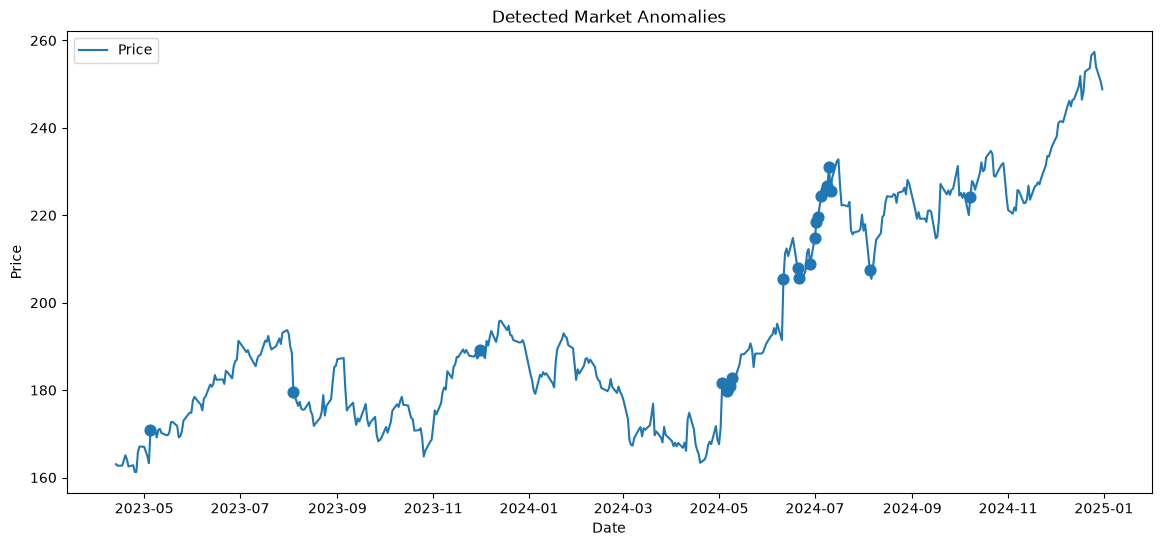

In [38]:
plt.figure(figsize=(14,6))

plt.plot(
    df["date"],
    df["close"],
    label="Price"
)

anomalies = df[df["anomaly"] == -1]

plt.scatter(
    anomalies["date"],
    anomalies["close"],
    s=60
)

plt.title("Detected Market Anomalies")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

    Interpretation

The blue points represent trading days identified as anomalous by the Isolation Forest model.

These points typically correspond to periods of:

unusually large returns,
sudden changes in volatility,
abnormal spectral energy,
irregular frequency-domain behavior.

In [39]:
df.to_csv(
    "../data/anomaly_dataset.csv",
    index=False
)

    Conclusion
The Isolation Forest model successfully identified anomalous market observations by combining statistical indicators with rolling spectral features extracted using FFT. Unlike traditional approaches that rely only on price-based indicators, the inclusion of frequency-domain characteristics provides additional information about hidden market dynamics. The resulting anomaly labels will serve as the target for supervised machine learning models in the next phase of the project.